In [47]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
from itertools import combinations
from scipy.stats import pearsonr
from scipy.stats import normaltest, shapiro
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
import statsmodels.api as sm
from scipy.stats import f_oneway

# 1. Connecting to the database in Google BigQuery (DA dataset)

auth.authenticate_user()
print("Authentication successful")
client = bigquery.Client(project="data-analytics-mate")

Authentication successful


In [48]:
query = """
SELECT

s.date as order_date,
s.ga_session_id,
sp.continent,
sp.country,
sp.device,
sp.browser,
sp. mobile_model_name,
sp.operating_system,
sp.language,
sp.name as traffic_source_inf,
sp.channel,
acc.id as user_id,
acc.is_verified,
acc.is_unsubscribed,
p.category as product_category,
p.name as product_name,
p.price as product_price,
p.short_description as short_prod_descr

FROM `data-analytics-mate.DA.session`s
left join `data-analytics-mate.DA.account_session`acs
on s.ga_session_id = acs.ga_session_id
left join `data-analytics-mate.DA.account`acc
on acs.account_id = acc.id
left join `data-analytics-mate.DA.session_params`sp
on s.ga_session_id = sp.ga_session_id
left join `data-analytics-mate.DA.order`o
on s.ga_session_id = o.ga_session_id
left join `data-analytics-mate.DA.product`p
on o.item_id = p.item_id
order by s.date

"""
query_job = client.query(query)
results = query_job.result()

#df = results.to_dataframe()
rows = [dict(row) for row in results]
df = pd.DataFrame(rows)
df.head()



,order_date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source_inf,channel,user_id,is_verified,is_unsubscribed,product_category,product_name,product_price,short_prod_descr
0,2020-11-01,65223751,Americas,United States,mobile,Chrome,<Other>,Web,en-us,(organic),Organic Search,NaN,NaN,NaN,None,None,NaN,None
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic),Organic Search,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(direct),Direct,NaN,NaN,NaN,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(direct),Direct,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(direct),Direct,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_date          349545 non-null  object 
 1   ga_session_id       349545 non-null  int64  
 2   continent           349545 non-null  object 
 3   country             349545 non-null  object 
 4   device              349545 non-null  object 
 5   browser             349545 non-null  object 
 6   mobile_model_name   349545 non-null  object 
 7   operating_system    349545 non-null  object 
 8   language            235279 non-null  object 
 9   traffic_source_inf  349545 non-null  object 
 10  channel             349545 non-null  object 
 11  user_id             27945 non-null   float64
 12  is_verified         27945 non-null   float64
 13  is_unsubscribed     27945 non-null   float64
 14  product_category    33538 non-null   object 
 15  product_name        33538 non-null

In [50]:
# converting the data type in the order_date column from dbdate to datetime

df["order_date"] = pd.to_datetime(df["order_date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_date          349545 non-null  datetime64[ns]
 1   ga_session_id       349545 non-null  int64         
 2   continent           349545 non-null  object        
 3   country             349545 non-null  object        
 4   device              349545 non-null  object        
 5   browser             349545 non-null  object        
 6   mobile_model_name   349545 non-null  object        
 7   operating_system    349545 non-null  object        
 8   language            235279 non-null  object        
 9   traffic_source_inf  349545 non-null  object        
 10  channel             349545 non-null  object        
 11  user_id             27945 non-null   float64       
 12  is_verified         27945 non-null   float64       
 13  is_unsubscribed     27945 non

# **Table Description**
The table contains 18 columns:
- 4 integer columns (Int64): ga_session_id, user_id, is_verified, is_unsubscribed;
- 12 categorical columns (object): continent, country, device, browser, mobile_model_name, operating_system, language, traffic_source_inf, channel, product_category, product_name, short_prod_descr;
- 1 datetime column: order_date;
- 1 float64 column: product_price

In [51]:
# number of unique sessions
print(f"number of unique sessions: {df['ga_session_id'].nunique()}")

number of unique sessions: 349545


In [52]:
# time period covered by the dataset
print(f" the time period considered is from {df['order_date'].min()} to {df['order_date'].max()}")

 the time period considered is from 2020-11-01 00:00:00 to 2021-01-31 00:00:00


In [53]:
# checking for missing values
print(df.isna().sum())

order_date                 0
ga_session_id              0
continent                  0
country                    0
device                     0
browser                    0
mobile_model_name          0
operating_system           0
language              114266
traffic_source_inf         0
channel                    0
user_id               321600
is_verified           321600
is_unsubscribed       321600
product_category      316007
product_name          316007
product_price         316007
short_prod_descr      316007
dtype: int64


In [54]:
# percentage of missing values in the table
print(df.isna().sum() /
      df.shape[0] * 100)

order_date             0.000000
ga_session_id          0.000000
continent              0.000000
country                0.000000
device                 0.000000
browser                0.000000
mobile_model_name      0.000000
operating_system       0.000000
language              32.689925
traffic_source_inf     0.000000
channel                0.000000
user_id               92.005321
is_verified           92.005321
is_unsubscribed       92.005321
product_category      90.405241
product_name          90.405241
product_price         90.405241
short_prod_descr      90.405241
dtype: float64


High number of missing values in the following columns:
- language — 114,266 missing values (33%): possibly some devices do not always send language information due to technical issues;
- user_id, is_verified, is_unsubscribed — 321,600 missing values (92%): 92% of website visitors are not registered;
- product_category, product_name, product_price, short_prod_descr — 316,007 missing values (90%): 90% of website visitors do not place any orders.

In [55]:
# which continents orders come from
print(df['continent'].unique())

['Americas' 'Europe' 'Africa' 'Asia' 'Oceania' '(not set)']


In [56]:
# number of countries per continent
print(df.groupby('continent')['country'].nunique().reset_index().sort_values(by="country", ascending=False).reset_index(drop = True) .rename(columns={"country": "number_of_countries"}))
print(f"\nTotal number of countries:    {df['country'].nunique()}")

   continent  number_of_countries
0     Europe                   38
1       Asia                   38
2   Americas                   24
3     Africa                    9
4    Oceania                    2
5  (not set)                    1

Total number of countries:    108


# **Overall Sales and User Behavior Analysis**


In [57]:

# continents and countries (top 5) with the highest sales and number of orders

# ranking continents by sales:
top_continents_by_sales = (df.groupby("continent", observed=False)["product_price"].sum().reset_index(name = "Total_sales").sort_values(by="Total_sales", ascending=False).reset_index(drop=True))
total_sales = df['product_price'].sum()
top_continents_by_sales['% of total'] = (top_continents_by_sales["Total_sales"] / total_sales * 100).round(2)

print(f"Rate of continents by sales  \n\n{top_continents_by_sales}")

# ranking continents by number of orders:
top_continents_by_sales_number = (df.groupby("continent", observed=False)["product_price"].count().reset_index(name="number_of_orders").sort_values(by="number_of_orders", ascending=False).reset_index(drop=True))
total_orders = df['product_price'].count()
top_continents_by_sales_number['% of total'] = (top_continents_by_sales_number['number_of_orders'] / total_orders * 100).round(2)
print(f"\nRate of continents by number of orders:  \n\n{top_continents_by_sales_number}")

# top 5 countries by sales:
top_countries_by_sales = (df.groupby("country", observed=False)["product_price"].sum().reset_index(name = "Total_sales").sort_values(by="Total_sales", ascending=False).head(5).reset_index(drop=True))
total_sales = df['product_price'].sum()
top_countries_by_sales['% of total'] = (top_countries_by_sales["Total_sales"] / total_sales * 100).round(2)

print(f"\nTop 5 countries by sales  \n\n{top_countries_by_sales}")

# top 5 countries by number of orders:
top_countries_by_sales_number = (df.groupby("country", observed=False)["product_price"].count().reset_index(name = "number_of_orders").sort_values(by="number_of_orders", ascending=False).head(5).reset_index(drop=True))
total_orders = df['product_price'].count()
top_countries_by_sales_number['% of total'] = (top_countries_by_sales_number["number_of_orders"] / total_orders * 100).round(2)
print(f"\nTop 5 countries by number of orders  \n\n{top_countries_by_sales_number}")
print(total_sales)

Rate of continents by sales  

   continent  Total_sales  % of total
0   Americas   17665280.0       55.25
1       Asia    7601298.3       23.78
2     Europe    5934624.2       18.56
3    Oceania     365230.2        1.14
4     Africa     331231.0        1.04
5  (not set)      74067.4        0.23

Rate of continents by number of orders:  

   continent  number_of_orders  % of total
0   Americas             18553       55.32
1       Asia              7950       23.70
2     Europe              6261       18.67
3    Oceania               364        1.09
4     Africa               339        1.01
5  (not set)                71        0.21

Top 5 countries by sales  

          country  Total_sales  % of total
0   United States   13943553.9       43.61
1           India    2809762.0        8.79
2          Canada    2437921.0        7.63
3  United Kingdom     938317.9        2.93
4          France     710692.8        2.22

Top 5 countries by number of orders  

          country  number_of_or

Americas is the undisputed leader, accounting for over 55% of total sales. The primary contributor is the United States (43.6% of global sales), with Canada (7.6%) as the second key market in the region.
Asia accounts for 23.7% of global sales, with India (8.8%) being the largest market in the region.
Europe is responsible for ~18.6% of sales. Key countries: United Kingdom (2.9%) and France (2.2%).

In [58]:
# ranking of product categories by total sales

top_categories_by_sales = (df.groupby("product_category")["product_price"].sum().reset_index(name = "Total_sales").sort_values(by="Total_sales", ascending=False).reset_index(drop=True))
top_categories_by_sales['% of total'] = (top_categories_by_sales['Total_sales'] / df['product_price'].sum()*100).round(2)
print(f"Top 10 product categories by sales  \n\n{top_categories_by_sales}")



Top 10 product categories by sales  

                        product_category  Total_sales  % of total
0                      Sofas & armchairs    8388254.5       26.24
1                                 Chairs    6147748.8       19.23
2                                   Beds    4919725.0       15.39
3             Bookcases & shelving units    3640818.1       11.39
4                   Cabinets & cupboards    2336499.5        7.31
5                      Outdoor furniture    2142222.2        6.70
6                         Tables & desks    1790307.5        5.60
7       Chests of drawers & drawer units     906562.5        2.84
8                          Bar furniture     735503.0        2.30
9                   Children's furniture     467697.0        1.46
10                     Nursery furniture     141607.0        0.44
11                        Café furniture     138168.0        0.43
12  Sideboards, buffets & console tables     126330.0        0.40
13                         Room divide

In [59]:
# ranking of product categories by total sales in the country with the highest sales (USA)
df_USA = df[df['country'] =='United States']
top_categories_by_sales_in_USA = (df_USA.groupby("product_category")["product_price"].sum().reset_index().sort_values(by="product_price", ascending=False).reset_index(drop=True))
top_categories_by_sales_in_USA['% of total'] = (top_categories_by_sales_in_USA['product_price'] / top_categories_by_sales_in_USA['product_price'].sum() * 100).round(2)
print(f"Top 10 product categories by sales in USA  \n\n{top_categories_by_sales_in_USA}")

Top 10 product categories by sales in USA  

                        product_category  product_price  % of total
0                      Sofas & armchairs      3707144.5       26.59
1                                 Chairs      2619773.8       18.79
2                                   Beds      2213058.0       15.87
3             Bookcases & shelving units      1567606.9       11.24
4                   Cabinets & cupboards       994545.5        7.13
5                      Outdoor furniture       929245.2        6.66
6                         Tables & desks       777865.0        5.58
7       Chests of drawers & drawer units       382388.0        2.74
8                          Bar furniture       330805.0        2.37
9                   Children's furniture       207575.0        1.49
10                     Nursery furniture        65998.0        0.47
11                        Café furniture        59000.0        0.42
12  Sideboards, buffets & console tables        58110.0        0.42
13 

In [60]:
# average order value per category
avg_order_amount_by_category = (df.groupby("product_category")["product_price"].mean().reset_index().sort_values(by="product_price", ascending=False).reset_index(drop=True).round())

print(f"Average order amount in each category: \n\n{avg_order_amount_by_category}")

# number of units sold per category
units_sold_by_categories = df.groupby("product_category")["product_price"].count().reset_index(name="units_sold").sort_values(by="units_sold", ascending=False).reset_index(drop=True)

print(f"\nUnits sold in each category: \n\n{units_sold_by_categories}")

Average order amount in each category: 

                        product_category  product_price
0                      Sofas & armchairs         1950.0
1                                   Beds         1681.0
2                                 Chairs         1033.0
3                   Cabinets & cupboards         1008.0
4                      Outdoor furniture          961.0
5   Sideboards, buffets & console tables          957.0
6                          Room dividers          821.0
7                          Bar furniture          674.0
8       Chests of drawers & drawer units          624.0
9                         Tables & desks          609.0
10            Bookcases & shelving units          477.0
11                        Café furniture          385.0
12                     Nursery furniture          359.0
13                  Children's furniture          275.0

Units sold in each category: 

                        product_category  units_sold
0             Bookcases & shelving

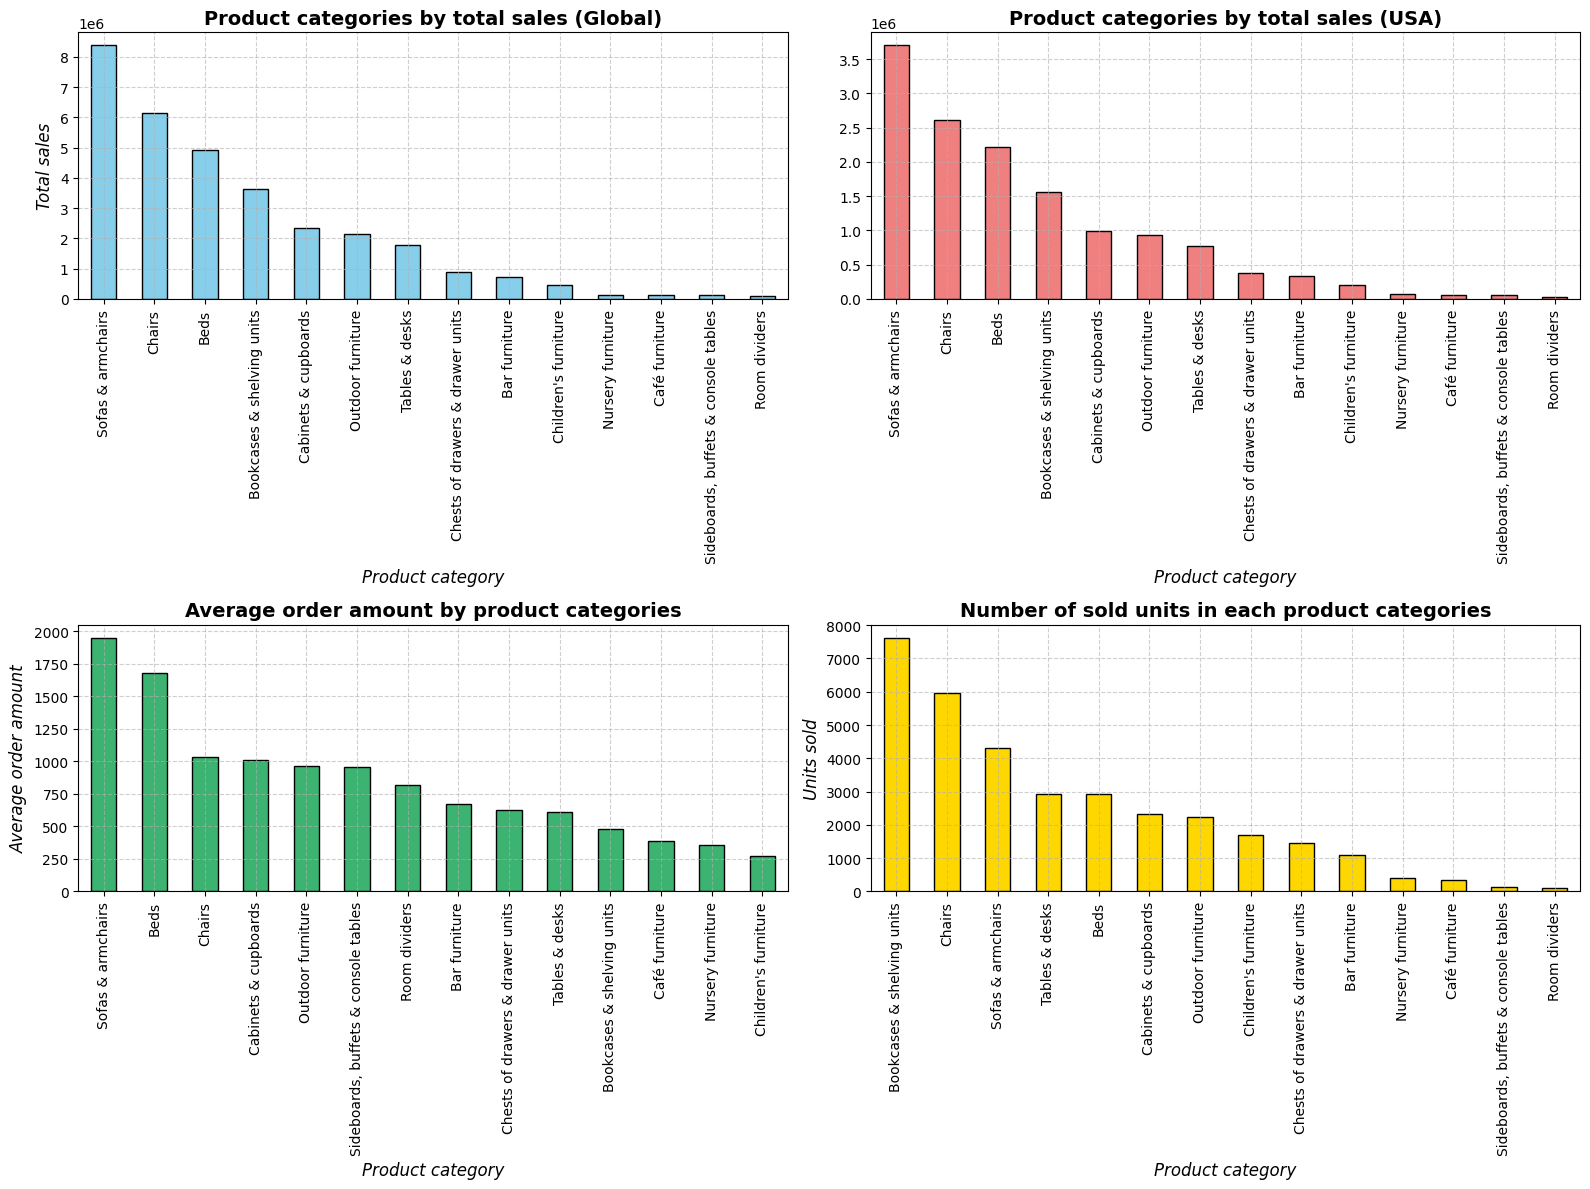

In [61]:
# Figure (2x2): comparison of product categories by total sales (global and USA),
# average order value and number of units sold

# data for charts
profit_by_category = df.groupby("product_category")["product_price"].sum().sort_values(ascending=False)
df_USA = df[df['country'] == 'United States']
top_categories_by_sales_in_USA = (df_USA.groupby("product_category")["product_price"].sum().sort_values(ascending=False))
avg_order_by_category = df.groupby("product_category")["product_price"].mean().sort_values(ascending=False)
number_of_sales = df.groupby("product_category")["product_price"].count().sort_values(ascending=False)

# Create a 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Total sales by category (Global)
profit_by_category.plot(kind="bar", color="skyblue", edgecolor="black", ax=axes[0, 0])
axes[0, 0].set_title("Product categories by total sales (Global)", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("Product category", fontstyle="italic", fontsize=12)
axes[0, 0].set_ylabel("Total sales", fontstyle="italic", fontsize=12)
axes[0, 0].grid(True, linestyle="--", alpha=0.6)
axes[0, 0].tick_params(axis="x", rotation=90)

# 2. Total sales by category (USA)
top_categories_by_sales_in_USA.plot(kind="bar", color="lightcoral", edgecolor="black", ax=axes[0, 1])
axes[0, 1].set_title("Product categories by total sales (USA)", fontsize=14, fontweight="bold")
axes[0, 1].set_xlabel("Product category", fontstyle="italic", fontsize=12)
axes[0, 1].set_ylabel("")
axes[0, 1].grid(True, linestyle="--", alpha=0.6)
axes[0, 1].tick_params(axis="x", rotation=90)

# 3. Average order value by category
avg_order_by_category.plot(kind="bar", color="mediumseagreen", edgecolor="black", ax=axes[1, 0])
axes[1, 0].set_title("Average order amount by product categories", fontsize=14, fontweight="bold")
axes[1, 0].set_xlabel("Product category", fontstyle="italic", fontsize=12)
axes[1, 0].set_ylabel("Average order amount", fontstyle="italic", fontsize=12)
axes[1, 0].grid(True, linestyle="--", alpha=0.6)
axes[1, 0].tick_params(axis="x", rotation=90)

# 4. Number of units sold per category
number_of_sales.plot(kind="bar", color="gold", edgecolor="black", ax=axes[1, 1])
axes[1, 1].set_title("Number of sold units in each product categories", fontsize=14, fontweight="bold")
axes[1, 1].set_xlabel("Product category", fontstyle="italic", fontsize=12)
axes[1, 1].set_ylabel("Units sold", fontstyle="italic", fontsize=12)
axes[1, 1].grid(True, linestyle="--", alpha=0.6)
axes[1, 1].tick_params(axis="x", rotation=90)

# Layout adjustment
plt.tight_layout()
plt.show()

**Categories with the highest revenue**

The top-selling categories are Sofas & armchairs, Chairs, Beds and Bookcases & shelving units, which together account for approximately 72% of total revenue.

**Average order amount**

The highest average order value is recorded in the following categories:
Sofas & armchairs — 1st place,
Beds — 2nd place,
Chairs — 3rd place.
At the same time, Bookcases & shelving units rank only 11th by average order value, indicating high demand but a lower price per unit.

**Number of units sold**

The top 3 categories by sales volume (in units) are:
Bookcases & shelving units — 1st place,
Chairs — 2nd place,
Sofas & armchairs — 3rd place.
The Beds category (2nd by revenue) ranks only 5th by number of units sold, highlighting its high unit price with lower order volume.

**Categories with the lowest revenue**

The lowest-performing group includes: Nursery furniture, Café furniture, Sideboards, buffets & console tables, and Room dividers, which together account for only ~1.5% of total revenue. Products in these categories also show the lowest demand.

**Comparison of global sales and USA**

The category revenue ranking in the USA almost perfectly mirrors the global ranking, confirming the key role of this market (accounting for approximately 44% of all sales).

In [62]:
 # top 10 most profitable products by category
top_products = (df.groupby(["product_category", "product_name"], observed=False)["product_price"].sum().reset_index(name = "Total_sales").sort_values(by="Total_sales", ascending=False).head(10).reset_index(drop=True))
print(f"Top 10 most profitable products  \n\n{top_products}")

# top 10 most profitable products in the most profitable category (Sofas & armchairs):
df_most_prof_category = df[df['product_category'] ==  "Sofas & armchairs"]
top_products_in_most_prof_categ = (df_most_prof_category.groupby("product_name")["product_price"].sum().reset_index(name="Total_sales").sort_values(by="Total_sales", ascending=False).head(10).reset_index(drop=True))
print(f"\nTop 10 most profitable products in most profitable category (Sofas & armchairs)  \n\n{top_products_in_most_prof_categ}")

# share of top 4 products in total revenue
total_profit = df["product_price"].sum()
top4_products = ["GRÖNLID", "LIDHULT", "VIMLE", "KIVIK"]
profit_top4 = df[df["product_name"].isin(top4_products)]["product_price"].sum()
share_top4_total = profit_top4 / total_profit * 100
print(f"\nShare of the 4 most profitable products in total profit: {share_top4_total:.2f}%")

# share of top 4 products within the Sofas & armchairs category
total_profit_sofas = df[df["product_category"] == "Sofas & armchairs"]["product_price"].sum()
profit_top4_sofas = df[(df["product_category"] == "Sofas & armchairs") & (df["product_name"].isin(top4_products))]["product_price"].sum()
share_top4_sofas = profit_top4_sofas / total_profit_sofas * 100
print(f"\nThe share of these 4 products within the Sofas & armchairs category: {share_top4_sofas:.2f}%")

print(f"\nTotal number of unique products: {df['product_name'].nunique()}")

Top 10 most profitable products  

             product_category product_name  Total_sales
0           Sofas & armchairs      GRÖNLID    1798185.0
1           Sofas & armchairs      LIDHULT    1375067.0
2           Sofas & armchairs        VIMLE    1152395.0
3           Sofas & armchairs        KIVIK     833563.0
4                        Beds      LIDHULT     802376.0
5  Bookcases & shelving units        BESTÅ     707693.0
6           Outdoor furniture     SOLLERÖN     604380.0
7           Sofas & armchairs     NORSBORG     576220.0
8           Sofas & armchairs   VALLENTUNA     574192.0
9                        Beds        VIMLE     540620.0

Top 10 most profitable products in most profitable category (Sofas & armchairs)  

  product_name  Total_sales
0      GRÖNLID    1798185.0
1      LIDHULT    1375067.0
2        VIMLE    1152395.0
3        KIVIK     833563.0
4     NORSBORG     576220.0
5   VALLENTUNA     574192.0
6   LANDSKRONA     507240.0
7    SÖDERHAMN     380184.0
8     DELAKTI

As we can see, 4 products — GRÖNLID, LIDHULT, VIMLE, and KIVIK — are the most profitable (out of 550 unique products in total), both across the entire company (accounting for 22.35% of total revenue) and within the most profitable category, Sofas & armchairs (accounting for 61.51% of category revenue). It is also worth noting NORSBORG and VALLENTUNA, which rank 5th and 6th within the Sofas & armchairs category, while placing 8th and 9th in the overall company ranking. In total, 6 out of the top 10 most profitable products belong to the Sofas & armchairs category.

In [63]:
# sales by device type and browser (as % of total sales)

# sales by device type
sales_by_device = (df.groupby("device")["product_price"].sum().reset_index().sort_values(by="product_price", ascending=False).reset_index(drop=True))
total_sales = df['product_price'].sum()
sales_by_device['% of total'] = (sales_by_device['product_price'] / total_sales * 100).round(2)
print(f"Sales by device with % of total \n\n{sales_by_device}")

# sales by device type and browser
sales_by_device_browser = (df.groupby(["device", "browser"])["product_price"].sum().reset_index().sort_values(by="product_price", ascending=False).reset_index(drop=True))

# adding share of total sales
total_sales = df["product_price"].sum()
sales_by_device_browser["% of total"] = (sales_by_device_browser["product_price"] / total_sales * 100).round(2)

print("Sales by device and browser:\n")
print(sales_by_device_browser)

Sales by device with % of total 

    device  product_price  % of total
0  desktop     18864039.0       59.00
1   mobile     12384225.8       38.73
2   tablet       723466.3        2.26
Sales by device and browser:

     device          browser  product_price  % of total
0   desktop           Chrome     15778375.2       49.35
1    mobile           Safari      5748221.2       17.98
2    mobile           Chrome      5667208.9       17.73
3   desktop           Safari      1515559.0        4.74
4   desktop             Edge       716444.3        2.24
5    mobile          <Other>       544545.3        1.70
6   desktop          Firefox       535659.6        1.68
7    mobile  Android Webview       392386.4        1.23
8    tablet           Chrome       381265.9        1.19
9   desktop          <Other>       318000.9        0.99
10   tablet           Safari       262763.8        0.82
11   tablet          <Other>        60808.6        0.19
12   mobile          Firefox        31864.0        0.10


**Sales by device type**

The majority of sales come from desktop devices — 59% of total revenue.
Mobile devices account for 38.7%, indicating active use of smartphones for shopping, though most users still complete their orders on desktop computers. Tablets have a minimal contribution (2.3%).

**Sales by device type and browser**

The largest share of sales comes from desktop + Chrome — 49.3% of total revenue.
This confirms Chrome's dominance among desktop users and highlights the importance of stable website performance in this environment.

Among mobile devices, there is an approximate parity between Safari (18%) and Chrome (17.7%).
This means that iPhone and Android users are almost equally active in making purchases, so the website should be optimized for both mobile platforms.

Other browsers (Edge, Firefox, <Other>, Android WebView) have a minor share — less than 3% each, however they should not be completely overlooked, as collectively they account for approximately 7–8% of total sales.

In [64]:
# 1. Filter data for Chrome browser only
df_chrome = df[df['mobile_model_name'] == 'Chrome'].copy()
print(df_chrome['device'].unique())

# 2. Group filtered data by device type
sales_by_chrome_device = (df_chrome.groupby("device")["product_price"].sum().reset_index().rename(columns={'product_price': 'Chrome Sales'}))

# 3. Calculate total sales for Chrome only
total_chrome_sales = sales_by_chrome_device['Chrome Sales'].sum()

# 4. Calculate % of sales for each device type (Desktop, Mobile, Tablet)
# relative to total Chrome sales
sales_by_chrome_device['% of Total Chrome Sales'] = (
    sales_by_chrome_device['Chrome Sales'] / total_chrome_sales * 100
).round(2)

# 5. Sort and display results
sales_by_chrome_device = sales_by_chrome_device.sort_values(
    by='Chrome Sales', ascending=False
).reset_index(drop=True)

print("Sales Distribution for 'Chrome' Browser by Device Type\n")
print(sales_by_chrome_device)

['desktop']
Sales Distribution for 'Chrome' Browser by Device Type

    device  Chrome Sales  % of Total Chrome Sales
0  desktop     8899523.9                    100.0


In [65]:
# sales by traffic source (as % of total sales)

sales_by_traffic_sourse = (df.groupby("traffic_source_inf")["product_price"].sum().reset_index().sort_values(by="product_price", ascending=False).reset_index(drop=True))
sales_by_traffic_sourse['% of total'] = (sales_by_traffic_sourse['product_price'] / total_sales * 100).round(2)
print(f"\nSales by traffic sourse with % of total \n\n{sales_by_traffic_sourse}")


Sales by traffic sourse with % of total 

  traffic_source_inf  product_price  % of total
0          (organic)     10935239.9       34.20
1           (direct)      7494923.4       23.44
2            <Other>      5897375.6       18.45
3         (referral)      5641855.2       17.65
4     (data deleted)      2002337.0        6.26


**Main traffic sources:**

Organic Search — 34.2%, Direct — 23.4%, Referral — 17.7%

In [66]:
# share of sessions with product orders
total_sessions = df['ga_session_id'].nunique()
sessions_with_orders = df[df['product_price'].notna()]['ga_session_id'].nunique()

share_sessions_with_orders = round(sessions_with_orders / total_sessions * 100, 2)

print(f"Share of sessions with orders: {share_sessions_with_orders}%")

Share of sessions with orders: 9.59%


In [67]:
# percentage of registered users who verified their email address

print(f"Percentage of registered users who confirmed their email address: {round(df[df['is_verified'] == 1]['is_verified'].count() / df['user_id'].count() * 100, 2)}%")


Percentage of registered users who confirmed their email address: 71.7%


In [68]:
# percentage of registered users who unsubscribed from the mailing list

print(f"Percentage of registered users who unsubscribed: {round(df[df['is_unsubscribed'] == 1]['is_unsubscribed'].count() / df['user_id'].count() * 100, 2)}%")


Percentage of registered users who unsubscribed: 16.94%


In [69]:
# do unsubscribed users behave differently (in terms of sales) compared to subscribed users?
df_for_unsubscribed = df[df['is_unsubscribed'] == 1]
df_for_subscribed = df[df['is_unsubscribed'] == 0]
avg_sales_unsub = df_for_unsubscribed.groupby("user_id")["product_price"].sum().mean()
avg_sales_sub = df_for_subscribed.groupby("user_id")["product_price"].sum().mean()
# difference in absolute values
diff_abs = avg_sales_sub - avg_sales_unsub

# difference in percentage relative to unsubscribed users
diff_percent = (diff_abs / avg_sales_unsub) * 100

print(f"Avg purchases per unsubscribed user: {round(avg_sales_unsub, 2)}")
print(f"Avg purchases per subscribed user: {round(avg_sales_sub, 2)}")
print(f"Difference in sales between subscribed and unsubscribed users: {round(avg_sales_sub-avg_sales_unsub, 2)} ({round(diff_percent, 2)}%)")

Avg purchases per unsubscribed user: 91.18
Avg purchases per subscribed user: 92.67
Difference in sales between subscribed and unsubscribed users: 1.49 (1.63%)


The purchasing behavior of unsubscribed and subscribed users shows no significant difference: subscribed users spend on average only 1.63% more.

In [70]:
# which countries have the highest number of registered users
df_registered_users = df[df['user_id'].notna()]
top_countries_by_registrations = (df_registered_users.groupby('country')['user_id'].count().reset_index().sort_values(by="user_id", ascending=False).head(5).reset_index(drop=True).rename(columns={"user_id": "number of registered users"}))
print(f"Top 5 countries with the highest number of registrations:\n\n{top_countries_by_registrations}")

Top 5 countries with the highest number of registrations:

          country  number of registered users
0   United States                       12384
1           India                        2687
2          Canada                        2067
3  United Kingdom                         859
4          France                         553


It can be concluded that countries with the highest sales volumes also have the largest number of registered users (the country rankings by sales volume and by number of registered users are identical).

# **Sales Dynamics Analysis**

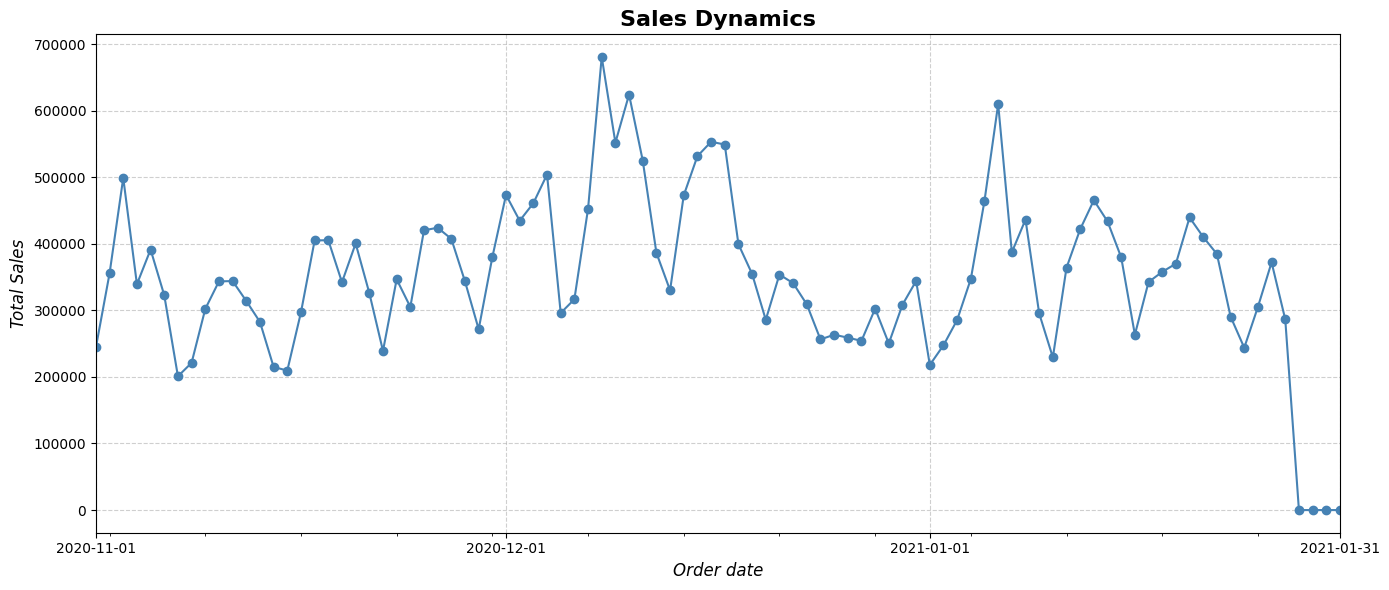

In [71]:
# overall sales dynamics

# group data by date and calculate total sales for each day
sales_by_date = df.groupby('order_date')['product_price'].sum()

# build the chart
plt.figure(figsize=(14, 6))
sales_by_date.plot(kind='line', marker='o', color='steelblue')

plt.title("Sales Dynamics", fontsize=16, fontweight="bold")
plt.xlabel("Order date", fontsize=12, fontstyle="italic")
plt.ylabel("Total Sales", fontsize=12, fontstyle="italic")

# date formatting
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

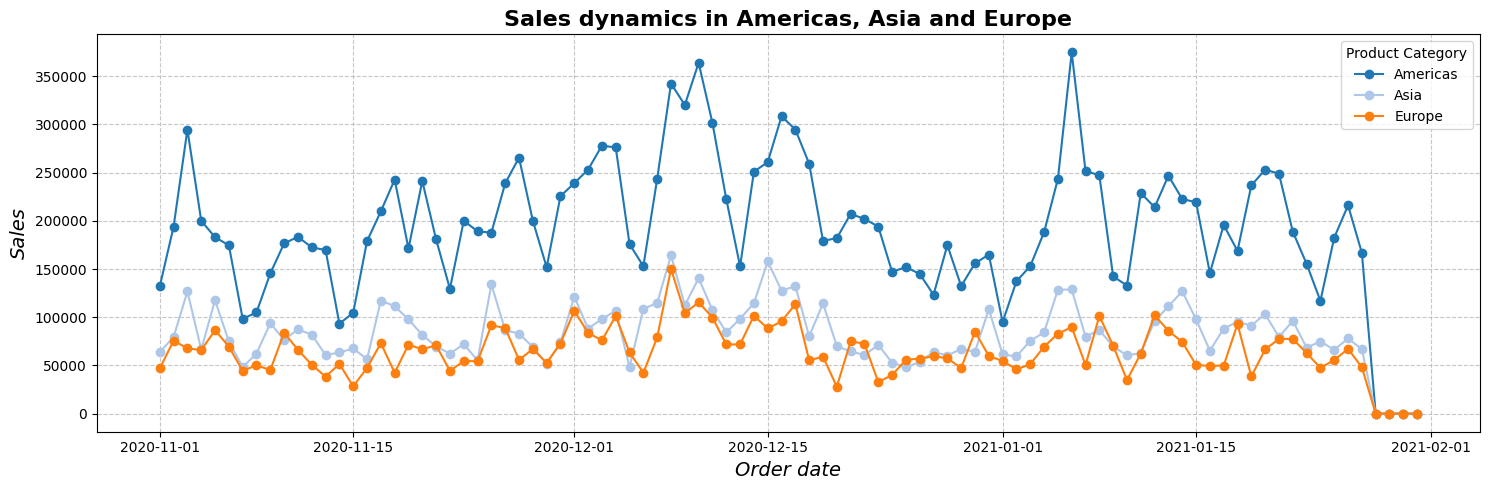

In [72]:
# sales dynamics in Americas, Asia and Europe

# group data by continent and calculate total sales
continent_totals = (df.groupby('continent')['product_price'].sum().sort_values(ascending=False))

# take top 3
top3 = continent_totals.head(3).index.tolist()

# filter data
top_continents = (df[df['continent'].isin(top3)].groupby(['continent', 'order_date'])['product_price'].sum().reset_index())
continents = top_continents['continent'].unique()

# build the chart
plt.figure(figsize=(15, 5))

colors = sns.color_palette('tab20', n_colors=len(continents))
color_map = dict(zip(continents, colors))

for continent in continents:
    continent_data = top_continents[top_continents['continent'] == continent]
    plt.plot(continent_data['order_date'], continent_data['product_price'], label=continent, marker='o', color=color_map.get(continent))

plt.xlabel("Order date", fontsize=14, fontstyle="italic")
plt.ylabel("Sales", fontsize=14, fontstyle="italic")
plt.title("Sales dynamics in Americas, Asia and Europe", fontsize=16, fontweight="bold")
plt.legend(title="Product Category")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


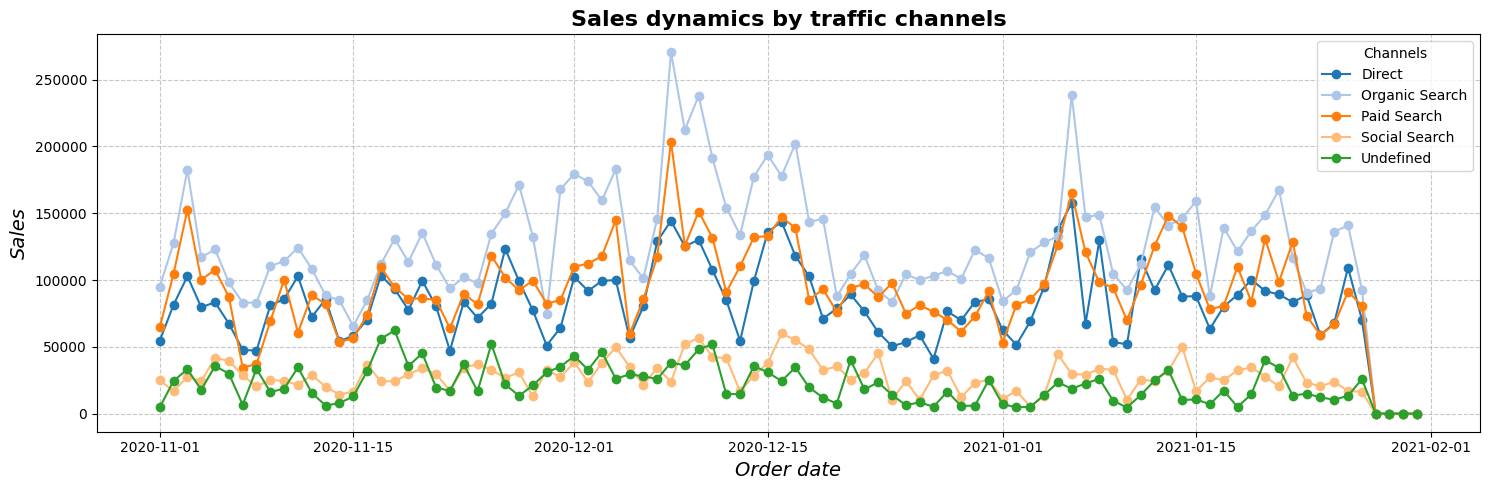

In [73]:
# sales dynamics by traffic channel

# group data by channel and calculate total sales for each day
channels_grouped = df.groupby(["channel", "order_date"])["product_price"].sum().reset_index()

# select unique traffic channels
channels = channels_grouped['channel'].unique()

# build the chart
plt.figure(figsize=(15, 5))

colors = sns.color_palette('tab20', n_colors=len(channels))
color_map = dict(zip(channels, colors))

for channel in channels:
    channel_data = channels_grouped[channels_grouped["channel"] == channel]
    plt.plot(channel_data["order_date"], channel_data["product_price"], label=channel, marker='o', color=color_map.get(channel))

plt.xlabel("Order date", fontsize=14, fontstyle="italic")
plt.ylabel("Sales", fontsize=14, fontstyle="italic")
plt.title("Sales dynamics by traffic channels", fontsize=16, fontweight="bold")
plt.legend(title="Channels")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


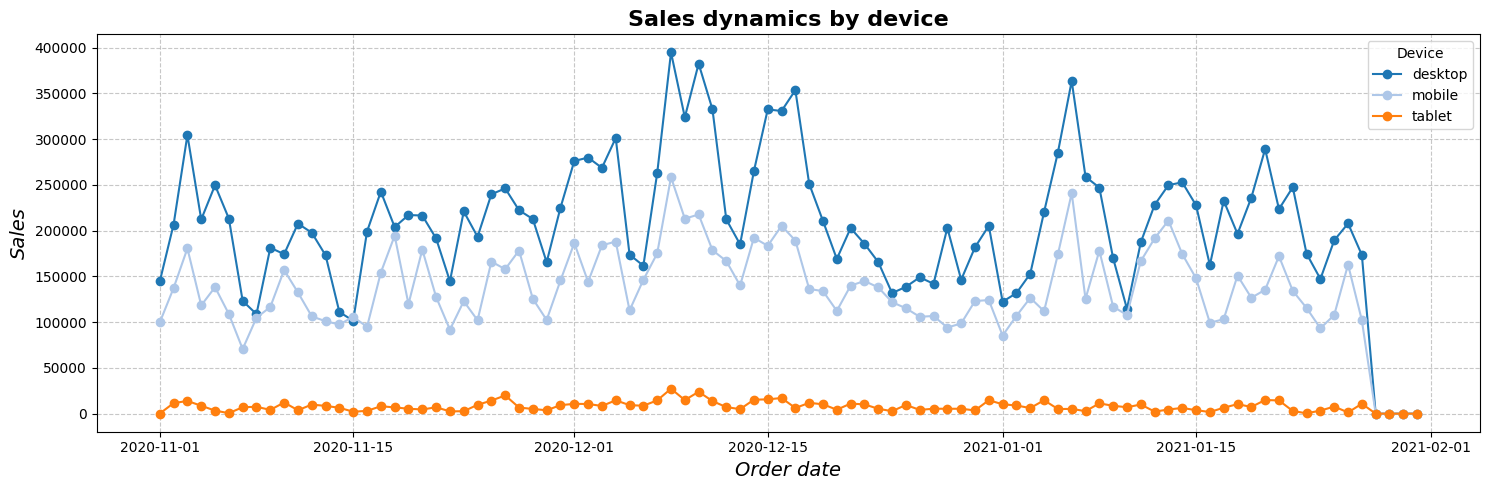

In [74]:
# sales dynamics by device type

# group data by device type and calculate total sales for each day
devices_grouped = df.groupby(["device", "order_date"])["product_price"].sum().reset_index()

# select unique device types
devices = devices_grouped['device'].unique()

# build the chart
plt.figure(figsize=(15, 5))

colors = sns.color_palette('tab20', n_colors=len(devices))
color_map = dict(zip(devices, colors))

for device in devices:
    device_data = devices_grouped[devices_grouped["device"] == device]
    plt.plot(device_data["order_date"], device_data["product_price"], label=device, marker='o', color=color_map.get(device))

plt.xlabel("Order date", fontsize=14, fontstyle="italic")
plt.ylabel("Sales", fontsize=14, fontstyle="italic")
plt.title("Sales dynamics by device", fontsize=16, fontweight="bold")
plt.legend(title="Device")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

**Overall dynamics**: a clear sales seasonality pattern is observed. The main peaks occur in the first half of December (highest peak — approximately 700K) during the pre-holiday period before Christmas and New Year, as well as in the first ten days of January (peak of approximately 610K). In the second half of January, demand declines following the end of the holiday season.

**By continent** (Americas, Asia, Europe), seasonality is most pronounced in the Americas, while Europe and Asia show relatively stable dynamics.

**Traffic channels**: Organic Search shows the largest seasonal fluctuations, while Direct and Paid Search remain more stable. Social and Undefined channels have a minimal impact on overall sales.

**Device types**: Desktop drives the largest peaks, Mobile occupies the middle position, and Tablet shows the lowest figures.

# **Pivot tables**

In [75]:
# number of sessions by traffic channel and device type

# filter out unknown values (None or NaN)
filtered_df = df.dropna(subset=['channel', 'device'])

# create a pivot table
sess_by_channel_and_device = pd.pivot_table(filtered_df, values='ga_session_id', index='channel', columns='device', aggfunc='count', margins=True, margins_name='Total')

# separate the Total row
total_row = sess_by_channel_and_device.loc['Total']

# sort the remaining rows
sess_by_channel_and_device = sess_by_channel_and_device.drop('Total').sort_values(by='Total', ascending=False)

# add the Total row at the bottom
sess_by_channel_and_device.loc['Total'] = total_row

print(f"Sessions number by traffic channel and device:\n {sess_by_channel_and_device}")

Sessions number by traffic channel and device:
 device          desktop  mobile  tablet   Total
channel                                        
Organic Search    72622   49014    2789  124425
Paid Search       55167   37034    2140   94341
Direct            47825   31745    1812   81382
Social Search     16288   10988     638   27914
Undefined         12527    8486     470   21483
Total            204429  137267    7849  349545


The highest number of sessions is generated by Organic Search, Paid Search and Direct channels, indicating the high effectiveness of organic and paid search, as well as strong user loyalty through direct visits.
The majority of traffic comes from Desktop and Mobile devices, while the share of Tablet users is negligible.

In [76]:
# total sales by product category (top 10 categories) across different countries (top 5 countries)

# group data by product category and identify top 10 categories by total sales
top_categories = (df.groupby("product_category", observed=False)["product_price"].sum().sort_values(ascending=False).head(10).index.tolist())

# group data by country and identify top 5 countries by total sales
top_countries = (df.groupby("country", observed=False)["product_price"].sum().sort_values(ascending=False).head(5).index.tolist())

# preserve the order of categories and countries
df['product_category'] = pd.Categorical(df['product_category'], categories=top_categories, ordered=True)
df['country'] = pd.Categorical(df['country'], categories=top_countries, ordered=True)

# filter data: keep only top 10 categories and top 5 countries
df_top = df[df["product_category"].isin(top_categories) & df["country"].isin(top_countries)]

# create a pivot table
sales_by_category_and_country = pd.pivot_table(df_top, values='product_price', index='product_category', columns='country', aggfunc='sum', fill_value=0, margins=True, margins_name='Total', observed=False)
print(f"Sales by top-10 product categories in top-5 countries:\n\n {sales_by_category_and_country}")




Sales by top-10 product categories in top-5 countries:

 country                           United States      India     Canada  \
product_category                                                        
Sofas & armchairs                     3707144.5   788430.0   692427.5   
Chairs                                2619773.8   544309.2   417740.8   
Beds                                  2213058.0   358319.5   354772.0   
Bookcases & shelving units            1567606.9   364507.4   278981.9   
Cabinets & cupboards                   994545.5   191888.0   181802.0   
Outdoor furniture                      929245.2   162289.4   185322.8   
Tables & desks                         777865.0   186157.5   132678.0   
Chests of drawers & drawer units       382388.0    73111.0    71952.0   
Bar furniture                          330805.0    57657.0    51724.0   
Children's furniture                   207575.0    39177.0    30264.0   
Total                                13730006.9  2765846.0  2397665

The product category revenue ranking overall aligns with the revenue ranking of these categories across the top 5 countries: Sofas & armchairs, Chairs and Beds consistently show the highest sales regardless of the country.

In [77]:
# monthly revenue from top 4 products

# create a new column 'order_year_month' in YYYY-MM format
df['order_year_month'] = df['order_date'].dt.to_period("M").astype(str)

# filter top 4 products
top_product_dynamics = df[df["product_name"].isin(top4_products)].copy()

# preserve the order of products
top_product_dynamics['product_name'] = pd.Categorical(top_product_dynamics['product_name'], categories=top4_products, ordered=True)

# create a pivot table
sales_by_top4_prod = pd.pivot_table(top_product_dynamics, values='product_price', index='order_year_month', columns='product_name', aggfunc='sum', fill_value=0, margins=True, margins_name='Total', observed=False)

print("Sales dynamics of top-4 products by month:\n\n", sales_by_top4_prod)


Sales dynamics of top-4 products by month:

 product_name        GRÖNLID    LIDHULT      VIMLE     KIVIK      Total
order_year_month                                                      
2020-11            726170.0   601472.0   520220.0  306845.0  2154707.0
2020-12            861305.0   888942.0   705660.0  350395.0  2806302.0
2021-01            711715.0   767094.0   484135.0  220523.0  2183467.0
Total             2299190.0  2257508.0  1710015.0  877763.0  7144476.0


Revenue from the top 4 products reached its peak in December 2020, which is observed both in total sales volume and for each individual product.
In November 2020 and January 2021, revenue was lower and remained at approximately the same level.

# **Statistical Relationship Analysis**

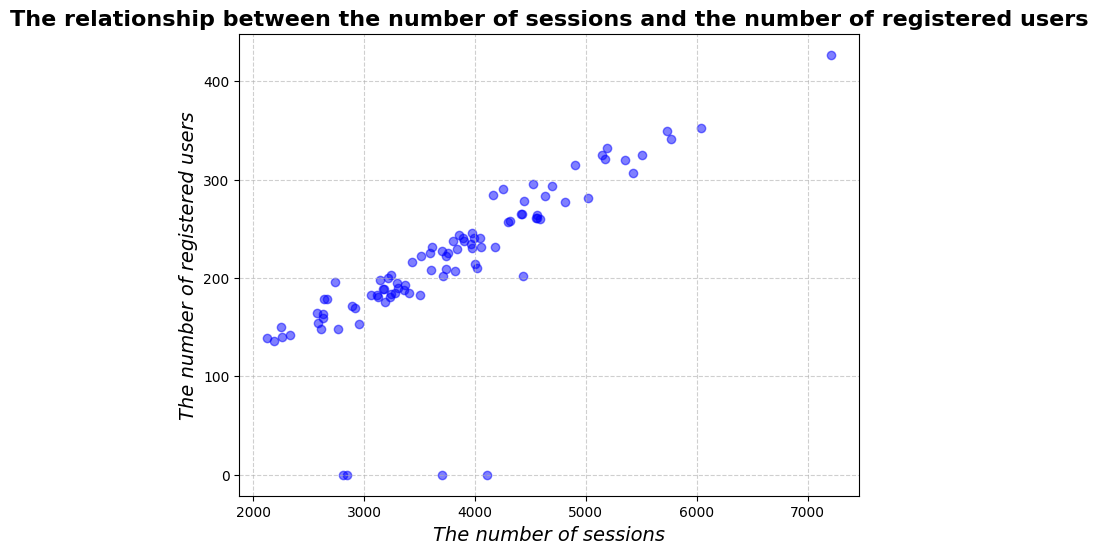

In [78]:
# relationship between the number of sessions and the number of registered users

# total number of unique sessions per day
sessions_per_day = df.groupby('order_date')['ga_session_id'].nunique().reset_index()

# number of unique users who completed registration
registered_users_per_day = df[df['is_verified'] == 1].groupby('order_date')['user_id'].nunique().reset_index()

# merge the tables
session_registred_data = pd.merge(sessions_per_day, registered_users_per_day, on='order_date', how='left').fillna(0)

# build the chart
plt.figure(figsize=(8,6))
plt.scatter(session_registred_data["ga_session_id"], session_registred_data["user_id"], color="blue", alpha=0.5)
plt.title("The relationship between the number of sessions and the number of registered users", fontsize=16, fontweight="bold")
plt.xlabel("The number of sessions", fontstyle="italic", fontsize=14)
plt.ylabel("The number of registered users", fontstyle="italic", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


The number of sessions and the number of registered users are correlated: as the number of sessions increases, the number of registered users increases as well.

In [79]:
# calculate p-value
print(f"Test statistic and p-value: {pearsonr(session_registred_data['ga_session_id'], session_registred_data['user_id'])}")

# calculate Pearson correlation coefficient
pearson_corr = session_registred_data["ga_session_id"].corr(session_registred_data["user_id"])
print(f"Pearson Correlation: {pearson_corr}")

Test statistic and p-value: PearsonRResult(statistic=np.float64(0.8012144328466945), pvalue=np.float64(8.811108737068605e-22))
Pearson Correlation: 0.8012144328466941


The relationship between the number of sessions and the number of registered users is statistically significant (p-value < 0.05). Based on the correlation coefficient (~0.801), it can be concluded that the variables have a fairly strong positive relationship. This indicates the effectiveness of the acquisition funnel.

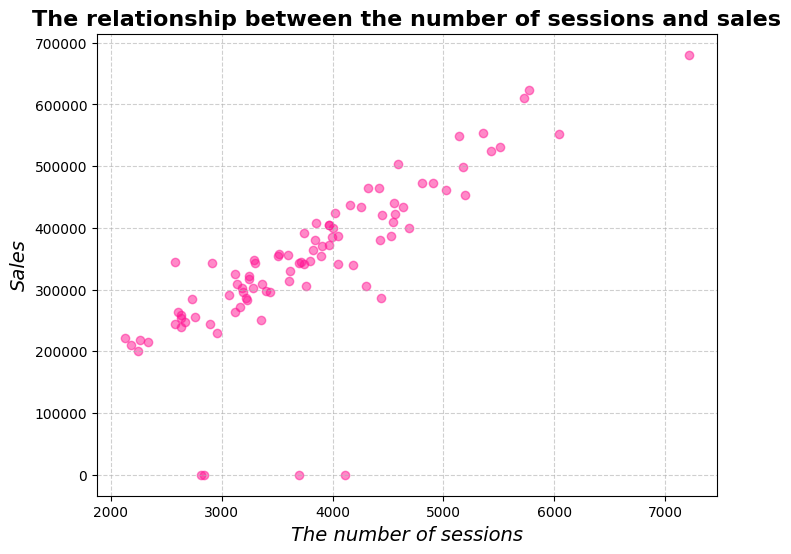

In [80]:
# relationship between the number of sessions and total sales for each date

# number of sessions per date
sessions_by_date = df.groupby(["order_date"])["ga_session_id"].count().reset_index()

# sales per date
sales_by_date = df.groupby(["order_date"])["product_price"].sum().reset_index()

# merge the tables
sessions_sales_by_date = pd.merge(sessions_by_date, sales_by_date, on="order_date", how="inner")

# rename columns
sessions_sales_by_date.rename(columns={"ga_session_id": "sessions_number", "product_price": "total_sales"}, inplace=True)

# build the chart
plt.figure(figsize=(8,6))
plt.scatter(sessions_sales_by_date["sessions_number"], sessions_sales_by_date["total_sales"], color="deeppink", alpha=0.5)
plt.title("The relationship between the number of sessions and sales", fontsize=16, fontweight="bold")
plt.xlabel("The number of sessions", fontstyle="italic", fontsize=14)
plt.ylabel("Sales", fontstyle="italic", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()



The number of sessions and total sales are correlated: as the number of sessions increases, sales increase as well.

In [81]:
# calculate p-value
print(f"Test statistic and p-value: {pearsonr(sessions_sales_by_date['sessions_number'], sessions_sales_by_date['total_sales'])}")

# calculate Pearson correlation coefficient
pearson_corr = sessions_sales_by_date["sessions_number"].corr(sessions_sales_by_date["total_sales"])
print(f"Pearson Correlation: {pearson_corr}")

Test statistic and p-value: PearsonRResult(statistic=np.float64(0.7910809164540891), pvalue=np.float64(6.483532312080735e-21))
Pearson Correlation: 0.7910809164540887


Since p-value < 0.05, the relationship between the number of sessions and sales is statistically significant. Based on the correlation coefficient of approximately 0.791, it can be concluded that the variables have a fairly strong positive relationship.

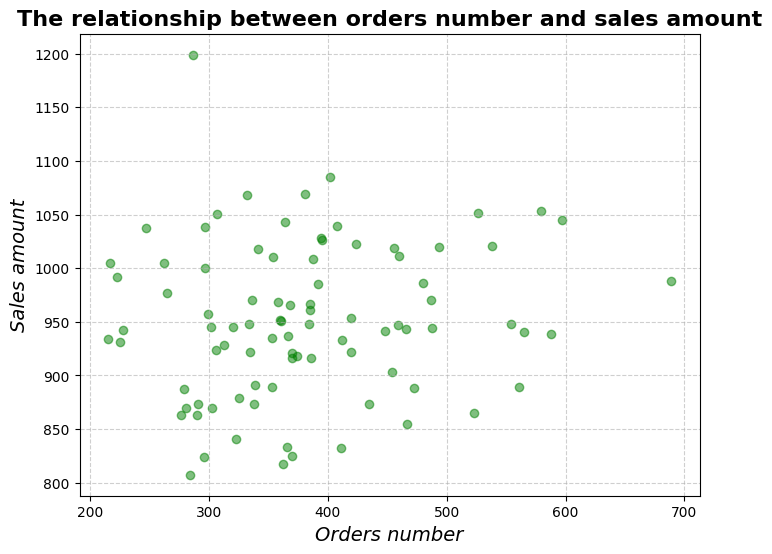

In [82]:
# relationship between average order value and number of units sold

# number of orders per date
orders_by_date = df.groupby("order_date")["product_price"].agg(orders_number='count').reset_index()

# average order value per date
avg_sales_by_date = df.groupby("order_date")["product_price"].agg(sales_amount='mean').reset_index()

# merge the tables
ord_avg_sales_by_date = pd.merge(orders_by_date, avg_sales_by_date, on="order_date", how="inner")

# remove rows with missing values
clean_data = ord_avg_sales_by_date.dropna(subset=["orders_number", "sales_amount"])

# build the chart
plt.figure(figsize=(8,6))
plt.scatter(clean_data["orders_number"], clean_data["sales_amount"], color="green", alpha=0.5)
plt.title("The relationship between orders number and sales amount", fontsize=16, fontweight="bold")
plt.xlabel("Orders number", fontstyle="italic", fontsize=14)
plt.ylabel("Sales amount", fontstyle="italic", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()



No clear relationship is observed between the number of orders and the average order value. The majority of average order values fluctuate within the range of approximately 800–1090. There is one outlier above this range (~1200), which can be considered separately (either a single high-value customer or a combination of expensive items in one order). It can be concluded that the average order value is fairly stable and does not show significant fluctuations.

In [83]:
# calculate p-value
print(f"Test statistic and p-value: {pearsonr(clean_data['orders_number'], clean_data['sales_amount'])}")

# calculate Pearson correlation coefficient
pearson_corr = clean_data["orders_number"].corr(clean_data["sales_amount"])
print(f"Pearson Correlation: {pearson_corr}")

Test statistic and p-value: PearsonRResult(statistic=np.float64(0.11582024744554015), pvalue=np.float64(0.28256438015876556))
Pearson Correlation: 0.11582024744554013


Since p-value > 0.05, the relationship between the number of orders and the average order value is not statistically significant. The average order value does not depend on the number of units sold.

In [84]:
# relationship between sales across top 3 continents

# select top 3 continents by total sales
top3_continents = df.groupby('continent')['product_price'].sum().sort_values(ascending=False).head(3).index.tolist()

# filter data
top_continents = (df[df['continent'].isin(top3_continents)].groupby(['continent', 'order_date'])['product_price'].sum().reset_index())

# create a pivot table
sales_by_top3_cont = pd.pivot_table(top_continents, values='product_price', index='order_date', columns='continent', aggfunc='sum', fill_value=0, observed=False)
print(sales_by_top3_cont)

# relationship between Americas vs Asia sales
# calculate p-value
print(f"\nTest statistic and p-value Americas vs Asia: {pearsonr(sales_by_top3_cont['Americas'], sales_by_top3_cont['Asia'])}")

# calculate Pearson correlation coefficient
pearson_corr = sales_by_top3_cont['Americas'].corr(sales_by_top3_cont['Asia'])
print(f"Pearson Correlation Americas vs Asia: {pearson_corr}")

# relationship between Americas vs Europe sales
# calculate p-value
print(f"\nTest statistic and p-value Americas vs Europe: {pearsonr(sales_by_top3_cont['Americas'], sales_by_top3_cont['Europe'])}")

# calculate Pearson correlation coefficient
pearson_corr = sales_by_top3_cont['Americas'].corr(sales_by_top3_cont['Europe'])
print(f"Pearson Correlation Americas vs Europe: {pearson_corr}")

# relationship between Asia vs Europe sales
# calculate p-value
print(f"\nTest statistic and p-value Asia vs Europe: {pearsonr(sales_by_top3_cont['Asia'], sales_by_top3_cont['Europe'])}")

# calculate Pearson correlation coefficient
pearson_corr = sales_by_top3_cont['Asia'].corr(sales_by_top3_cont['Europe'])
print(f"Pearson Correlation Asia vs Europe: {pearson_corr}")

continent   Americas      Asia   Europe
order_date                             
2020-11-01  132002.5   63823.0  46908.0
2020-11-02  193861.0   79370.0  75710.8
2020-11-03  294529.8  126737.8  67692.0
2020-11-04  200009.5   66602.0  65915.0
2020-11-05  182988.2  117608.4  86540.0
...              ...       ...      ...
2021-01-27  166735.5   66783.1  48156.1
2021-01-28       0.0       0.0      0.0
2021-01-29       0.0       0.0      0.0
2021-01-30       0.0       0.0      0.0
2021-01-31       0.0       0.0      0.0

[92 rows x 3 columns]

Test statistic and p-value Americas vs Asia: PearsonRResult(statistic=np.float64(0.7920245629479414), pvalue=np.float64(5.409189396197475e-21))
Pearson Correlation Americas vs Asia: 0.7920245629479415

Test statistic and p-value Americas vs Europe: PearsonRResult(statistic=np.float64(0.7705864582886499), pvalue=np.float64(2.6714492240629956e-19))
Pearson Correlation Americas vs Europe: 0.7705864582886501

Test statistic and p-value Asia vs Europe: Pear

A fairly strong positive correlation is observed between sales across all continents (coefficients: Americas – Asia: 0.79, Americas – Europe: 0.77, Asia – Europe: 0.76). Since p-value < 0.05 for all continent pairs, the relationships are statistically significant. This suggests that demand for our products changes synchronously across different regions, likely driven by seasonal factors or global marketing campaigns.


Correlations between traffic channels

     Channel 1      Channel 2  Correlation Coefficient r  p-value Significant
        Direct Organic Search                      0.838 2.19e-25         Yes
        Direct    Paid Search                      0.814 5.90e-23         Yes
        Direct  Social Search                      0.604 1.83e-10         Yes
        Direct      Undefined                      0.518 1.28e-07         Yes
Organic Search    Paid Search                      0.870 2.14e-29         Yes
Organic Search  Social Search                      0.583 1.07e-09         Yes
Organic Search      Undefined                      0.526 7.23e-08         Yes
   Paid Search  Social Search                      0.596 3.53e-10         Yes
   Paid Search      Undefined                      0.522 9.51e-08         Yes
 Social Search      Undefined                      0.455 5.16e-06         Yes


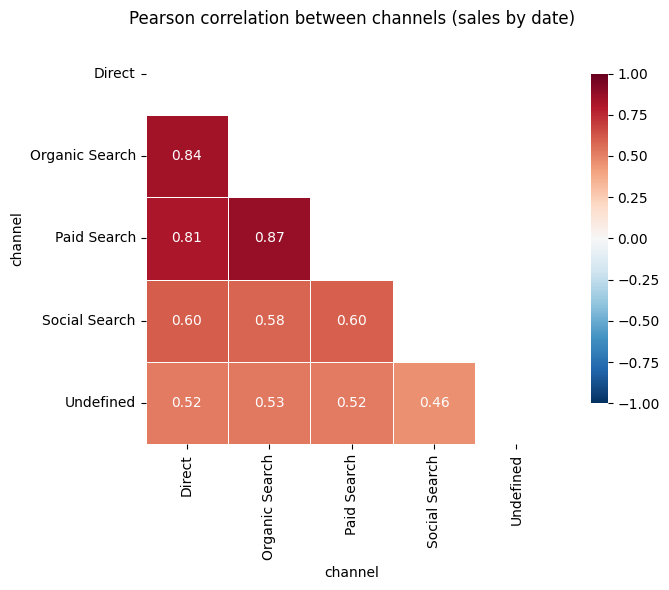

Sales by channel with % of total 

          channel  total_sales  % of total
0  Organic Search   11433151.6       35.76
1     Paid Search    8511049.4       26.62
2          Direct    7494923.4       23.44
3   Social Search    2532105.7        7.92
4       Undefined    2000501.0        6.26


In [85]:
# relationship between sales across different traffic channels

# group data
sales_by_channels = (df.groupby(['channel', 'order_date'])['product_price'].sum().reset_index())

# create a pivot table
sales_by_channels_pivot = pd.pivot_table(sales_by_channels, values='product_price', index='order_date', columns='channel', aggfunc='sum', observed=False)

# remove rows with missing values
sales_by_channels_pivot = sales_by_channels_pivot.dropna()

# calculate Pearson correlation coefficient and p-value
chanels_results = []
channels = sales_by_channels_pivot.columns.tolist()

for i in range(len(channels)):
    for j in range(i+1, len(channels)):
        ch1, ch2 = channels[i], channels[j]
        r, p = pearsonr(sales_by_channels_pivot[ch1], sales_by_channels_pivot[ch2])
        chanels_results.append({'Channel 1': ch1, 'Channel 2': ch2, 'Correlation Coefficient r': round(r, 3), 'p-value': f"{p:.2e}", 'Significant': 'Yes' if p < 0.05 else 'No'})

# display as a table
channel_correlation_df = pd.DataFrame(chanels_results)
print("\nCorrelations between traffic channels\n")
print(channel_correlation_df.to_string(index=False))

# build correlation matrix
corr_matrix = sales_by_channels_pivot[channels].corr(method="pearson")

plt.figure(figsize=(8,6))
# remove upper triangle for a cleaner view
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# build heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, mask=mask, square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title("Pearson correlation between channels (sales by date)")
plt.tight_layout()
plt.show()

# sales by channel
sales_by_channel = (df.groupby("channel")["product_price"].sum().reset_index(name='total_sales').sort_values(by="total_sales", ascending=False).reset_index(drop=True))
total_sales = df['product_price'].sum()
sales_by_channel['% of total'] = (sales_by_channel['total_sales'] / total_sales * 100).round(2)
print(f"Sales by channel with % of total \n\n{sales_by_channel}")

A positive statistically significant correlation is observed between all channels (p-value < 0.05). The strongest correlations are between Organic Search – Direct (r = 0.84), Organic Search – Paid Search (r = 0.87), and Paid Search – Direct (r = 0.81), which are the combinations of channels generating the highest number of orders (85.82%). For other channel combinations, the correlation is weaker (r ≈ 0.5).
This suggests that demand changes synchronously across channels, likely driven by seasonal factors or global marketing campaigns.

['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units', 'Cabinets & cupboards']

Correlations between top 5 categories

                Category 1                 Category 2  Correlation Coefficient r  p-value Significant
         Sofas & armchairs                     Chairs                      0.578 3.64e-09         Yes
         Sofas & armchairs                       Beds                      0.535 7.69e-08         Yes
         Sofas & armchairs Bookcases & shelving units                      0.666 1.41e-12         Yes
         Sofas & armchairs       Cabinets & cupboards                      0.658 3.42e-12         Yes
                    Chairs                       Beds                      0.554 2.08e-08         Yes
                    Chairs Bookcases & shelving units                      0.637 2.50e-11         Yes
                    Chairs       Cabinets & cupboards                      0.573 5.47e-09         Yes
                      Beds Bookcases & shelving un

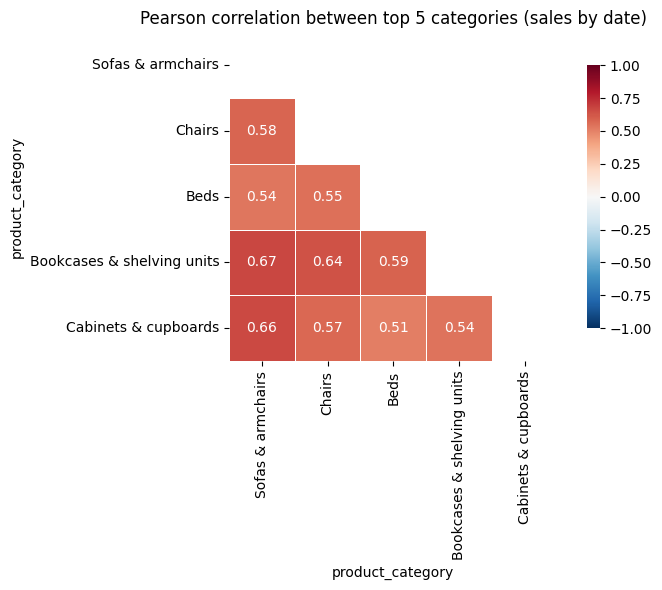

In [86]:
# relationship between sales across top 5 product categories

# select top 5 product categories by total sales
top_categories = (df.groupby("product_category", observed=False)["product_price"].sum().sort_values(ascending=False).head(5).index.tolist())
print(top_categories)

# filter data
top5 = (df[df['product_category'].isin(top_categories)])

# create a pivot table
sales_by_category_pivot = pd.pivot_table(top5, values='product_price', index='order_date', columns='product_category', aggfunc='sum', observed=True)

# remove rows with missing values
sales_by_category_pivot = sales_by_category_pivot.dropna()

# calculate Pearson correlation coefficient and p-value
category_results = []
categories = sales_by_category_pivot.columns.tolist()

for i in range(len(categories)):
    for j in range(i+1, len(categories)):
        cat1, cat2 = categories[i], categories[j]
        r, p = pearsonr(sales_by_category_pivot[cat1], sales_by_category_pivot[cat2])
        category_results.append({'Category 1': cat1, 'Category 2': cat2, 'Correlation Coefficient r': round(r, 3), 'p-value': f"{p:.2e}", 'Significant': 'Yes' if p < 0.05 else 'No'})

# display as a table
categories_correlation_df = pd.DataFrame(category_results)
print("\nCorrelations between top 5 categories\n")
print(categories_correlation_df.to_string(index=False))

# build correlation matrix
corr_matrix_category = sales_by_category_pivot[categories].corr(method="pearson")

plt.figure(figsize=(8,6))
# remove upper triangle for a cleaner view
mask = np.triu(np.ones_like(corr_matrix_category, dtype=bool))

# build heatmap
sns.heatmap(corr_matrix_category, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, mask=mask, square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title("Pearson correlation between top 5 categories (sales by date)")
plt.tight_layout()
plt.show()



A positive statistically significant correlation is observed between all top 5 product categories (p-value < 0.05). The correlation coefficients across all category combinations do not vary significantly (averaging approximately 0.59). This suggests that demand changes synchronously across categories, likely driven by seasonal factors or global marketing campaigns.

# **Statistical Analysis of Differences Between Groups**

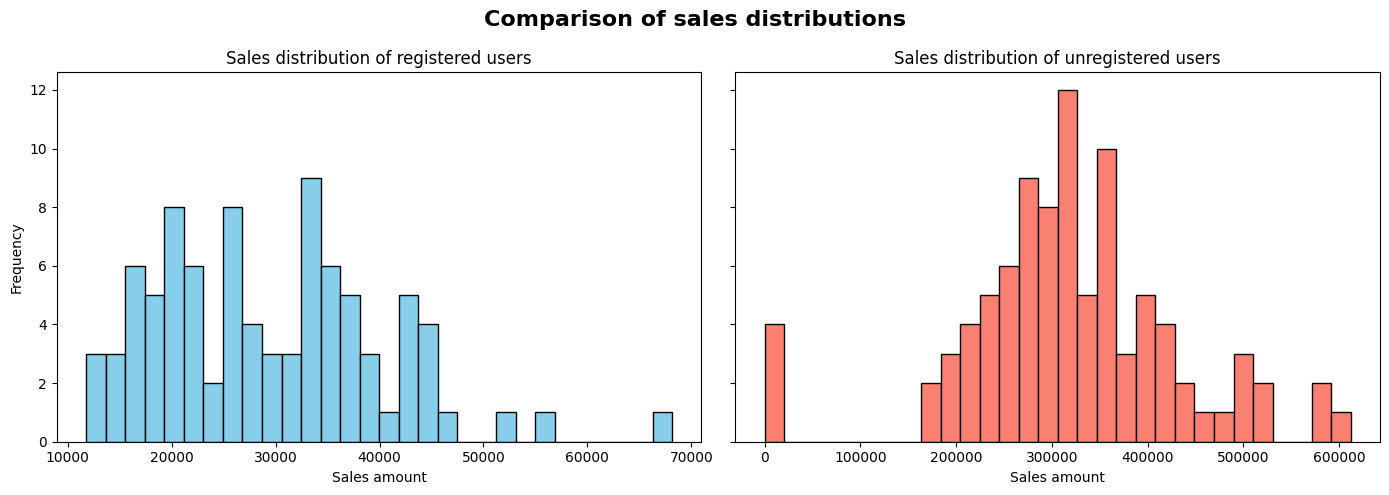

Normaltest for registred users p-value: 0.010929121653065912
Normaltest for not registred users p-value: 0.026362411185738954


In [87]:
# sales analysis per date for registered and unregistered users

# group sales of registered users by order date
df_registred = df[df['user_id'].notna()].groupby('order_date')['product_price'].sum().reset_index(name='registred_sales')

# group sales of unregistered users by order date
df_not_registred = df[df['user_id'].isna()].groupby('order_date')['product_price'].sum().reset_index(name='not_registred_sales')

# create a merged table with registered and unregistered user data
merg_registr_notregistr = pd.merge(df_registred, df_not_registred, on='order_date', how='outer').fillna(0)

# create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# histogram for registered users
axes[0].hist(df_registred['registred_sales'], bins=30, color="skyblue", edgecolor="black")
axes[0].set_title("Sales distribution of registered users")
axes[0].set_xlabel("Sales amount")
axes[0].set_ylabel("Frequency")

# histogram for unregistered users
axes[1].hist(df_not_registred['not_registred_sales'], bins=30, color="salmon", edgecolor="black")
axes[1].set_title("Sales distribution of unregistered users")
axes[1].set_xlabel("Sales amount")

# add a title for the entire figure
fig.suptitle("Comparison of sales distributions", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()


# виконуємо Normaltest
_, p_value_normaltest_registred = normaltest(df_registred['registred_sales'])
_, p_value_normaltest_not_registred = normaltest(df_not_registred['not_registred_sales'])

print(f"Normaltest for registred users p-value: {p_value_normaltest_registred}")
print(f"Normaltest for not registred users p-value: {p_value_normaltest_not_registred}")


Registered users: p-value = 0.01 < 0.05 — the distribution is not normal.

Not registered users: p-value = 0.026 < 0.05 — the distribution is not normal.

In [88]:
# since both samples are non-normal, we apply the Mann-Whitney U test

stat, p_value = mannwhitneyu(merg_registr_notregistr['registred_sales'], merg_registr_notregistr['not_registred_sales'])

print(f"U-statistic: {stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("There is a significant difference between order amount of registred and not registred users.")
else:
    print("There is no significant difference between order amount of registred and not registred users.")

U-statistic: 360.0
P-value: 8.379540669190225e-27
There is a significant difference between order amount of registred and not registred users.


In [89]:
# calculate total sales, number of orders and average order value for registered users
df_registred_order_amount = df[df['user_id'].notna()]['product_price'].sum()
df_registred_order_number = df[df['user_id'].notna()]['product_price'].count()
df_registred_avg_order_amount = (df_registred_order_amount/df_registred_order_number).round(0)

# calculate total sales, number of orders and average order value for unregistered users
df_not_registred_order_amount = df[df['user_id'].isna()]['product_price'].sum()
df_not_registred_order_number = df[df['user_id'].isna()]['product_price'].count()
df_not_registred_avg_order_amount = (df_not_registred_order_amount/df_not_registred_order_number).round(0)

print(f"Order amount of registred users: {df_registred_order_amount}")
print(f"Order number of registred users: {df_registred_order_number}")
print(f"Order amount of not registred users: {df_not_registred_order_amount:.1f}")
print(f"Order number of not registred users: {df_not_registred_order_number}")
print(f"Average order amount of registred users: {df_registred_avg_order_amount}")
print(f"Average order amount of not registred users: {df_not_registred_avg_order_amount}")

Order amount of registred users: 2582518.5
Order number of registred users: 2781
Order amount of not registred users: 29389212.6
Order number of not registred users: 30757
Average order amount of registred users: 929.0
Average order amount of not registred users: 956.0


Conclusion: the difference in sales between registered and unregistered users is statistically significant (p-value < 0.05). Sales of registered users differ significantly from those of unregistered users. Unregistered users are considerably more active (their total order value is 11 times higher than that of registered users) and account for the majority of sales, although the average order value is similar for both groups (929 for registered users and 956 for unregistered users). This suggests that:
- Demand exists even without loyalty: the product is competitive and meets customer needs.
- Registration does not provide sufficient value (bonuses, discounts, faster checkout), or there may be barriers during registration (excessive form fields, verification steps, complex sign-up process).
- Registration is a weak point that requires attention.


In [90]:
# analysis of the number of sessions by traffic channel

# group data: number of sessions per channel and date
sessions_by_channels = (df.groupby(['channel', 'order_date'])['ga_session_id'].count().reset_index(name='sessions_count'))

# create a dictionary: channel → array of session counts by date
channel_sessions = {ch: group['sessions_count'].values for ch, group in sessions_by_channels.groupby('channel')}

# apply Kruskal-Wallis test, as it is used for comparing more than two samples
stat, p_value = kruskal(*channel_sessions.values())

print(f"Kruskal-Wallis H-statistic: {stat:.3f}, p-value: {p_value:.4f}")

# interpretation
if p_value < 0.05:
    print("There are statistically significant differences between the number of sessions in different channels.")
else:
    print("No statistically significant differences were found between the channels.")


sessions_number_by_channels = (df.groupby(['channel'])['ga_session_id'].count().reset_index(name='sessions_count').sort_values(by="sessions_count", ascending=False).reset_index(drop=True))

print(sessions_number_by_channels)


Kruskal-Wallis H-statistic: 368.981, p-value: 0.0000
There are statistically significant differences between the number of sessions in different channels.
          channel  sessions_count
0  Organic Search          124425
1     Paid Search           94341
2          Direct           81382
3   Social Search           27914
4       Undefined           21483


Based on the Kruskal-Wallis test results (p-value < 0.05), statistically significant differences in the number of sessions across different traffic channels have been established.

The highest number of sessions is generated by Organic Search, Paid Search and Direct channels, while the lowest is produced by Social Search and Undefined channels.

In [91]:
# comparison of the share of organic search sessions in Europe and Americas

# filter data for Europe — keep only organic search traffic
df_Europe = df[(df['continent'] == 'Europe') & (df['channel'] == 'Organic Search')]

# count the number of organic sessions in Europe
session_number_for_Europe = df_Europe['ga_session_id'].count()

# count the total number of all sessions in Europe (regardless of channel)
total_sessions_Europe = df[df['continent'] == 'Europe']['ga_session_id'].count()

# filter data for Americas — keep only organic search traffic
df_Americas = df[(df['continent'] == 'Americas') & (df['channel'] == 'Organic Search')]

# count the number of organic sessions in Americas
session_number_for_Americas = df_Americas['ga_session_id'].count()

# count the total number of all sessions in Americas (regardless of channel)
total_sessions_Americas = df[df['continent'] == 'Americas']['ga_session_id'].count()

# perform z-test to check for a statistically significant difference
# between the share of organic sessions in Europe and Americas
z_stat, p_value = sm.stats.proportions_ztest([session_number_for_Europe, session_number_for_Americas], [total_sessions_Europe, total_sessions_Americas])

print(f"z-test statistic: {z_stat:.3f}, p-value: {p_value:.3f}")

# interpretation
if p_value < 0.05:
    print("There is a statistically significant difference between the share of sessions with organic traffic in Europe and Americas")
else:
    print("No statistically significant difference between the share of sessions with organic traffic in Europe and Americas")

print(f"The share of sessions with organic traffic in Europe: {session_number_for_Europe / total_sessions_Europe * 100:.2f}%")
print(f"The share of sessions with organic traffic in Americas: {session_number_for_Americas / total_sessions_Americas * 100:.2f}%")

z-test statistic: 0.290, p-value: 0.772
No statistically significant difference between the share of sessions with organic traffic in Europe and Americas
The share of sessions with organic traffic in Europe: 35.61%
The share of sessions with organic traffic in Americas: 35.55%


Based on the proportions z-test results (p-value = 0.772), no statistically significant difference was found between the share of organic search sessions in Europe and the Americas.
The share of organic search sessions is:
Europe — 35.61%,
Americas — 35.55%.
This means that users from both regions use organic search to visit the website at an equal rate, indicating that the differences in traffic structure are not significant.

In [92]:
# analysis of average revenue from the most profitable product by continent

# find the most profitable product
top_product = (df.groupby('product_name')['product_price'].sum().idxmax())

# filter data for this product
df_top = df[df['product_name'] == top_product]

# calculate total revenue by continent
continent_profit = (df_top.groupby(['continent', 'order_date'])['product_price'].sum().reset_index(name='daily_profit'))

# use ANOVA to compare average revenue across continents
# group data
groups = [g['daily_profit'].values for _, g in continent_profit.groupby('continent')]

# apply ANOVA test
stat, p = f_oneway(*groups)

print(f"ANOVA F-statistic: {stat:.3f}, p-value: {p:.4f}")
print(f"Top product: {top_product}")

# interpretation
if p < 0.05:
    print("The average daily profit from this product varies statistically between continents.")
else:
    print("There are no statistically significant differences in average daily profit between continents.")

# create a table with total revenue and revenue share by continent
profit_top_prod_by_continent = (df_top.groupby('continent')['product_price'].sum().reset_index(name='total_profit'))
total_profit_all = profit_top_prod_by_continent['total_profit'].sum()
profit_top_prod_by_continent['percent_of_total'] = (profit_top_prod_by_continent['total_profit'] / total_profit_all * 100).round(2)
profit_top_prod_by_continent = (profit_top_prod_by_continent.sort_values(by="total_profit", ascending=False).reset_index(drop=True))

print(profit_top_prod_by_continent)

ANOVA F-statistic: 17.631, p-value: 0.0000
Top product: GRÖNLID
The average daily profit from this product varies statistically between continents.
   continent  total_profit  percent_of_total
0   Americas     1209440.0             52.60
1       Asia      526955.0             22.92
2     Europe      497105.0             21.62
3     Africa       35765.0              1.56
4    Oceania       22900.0              1.00
5  (not set)        7025.0              0.31


Based on the ANOVA test results (p-value < 0.05), it has been established that the average daily revenue from the most profitable product GRÖNLID differs statistically across continents. More than half of the revenue (52.6%) is generated by the Americas, followed by Asia (22.9%) and Europe (21.6%).


## **Conclusions and Recommendations**

1. The United States accounts for 43.6% of total sales, making it a strategic research priority. It is recommended to conduct in-depth market research in the US (competitor analysis, advertising campaigns, customer surveys, reviews) to identify key success factors, and then scale the insights gained to other regions.

2. Ensure priority supply of products in the Sofas & armchairs, Chairs, Beds, and Bookcases & shelving units categories, which together account for 72% of revenue. In particular, maintain availability of high-value categories (Beds) during peak seasons (November–December).

3. The categories Nursery furniture, Café furniture, Sideboards, buffets & console tables, and Room dividers account for only 1.5% of revenue. It is recommended to conduct a margin analysis and either stimulate demand through promotional discounts or gradually phase out these products, focusing resources on profitable categories.

4. The majority of sales are made via Chrome on desktop devices (~49%), however mobile Safari and Chrome users together account for over 35% of revenue. This highlights the need to prioritize mobile optimization, especially for iOS and Android, while maintaining stable performance in Chrome as the primary sales channel.

5. Given the seasonal nature of sales, key marketing activities (discounts, email campaigns, advertising) should be launched as early as the beginning of November. In particular, ensure sufficient stock of top products (GRÖNLID, LIDHULT, VIMLE, KIVIK) ahead of the peak season.

6. The strong positive correlation between sales across different continents (r ≈ 0.77–0.79, p < 0.05) indicates that global marketing campaigns simultaneously impact multiple regions. It is recommended to plan synchronized marketing launches across key regions: Americas, Asia, and Europe.

7. Sales from unregistered users account for the majority of revenue (11 times more than registered users), with nearly identical average order values. This suggests that registration does not provide added value or is overly complex. Recommendations:
   - simplify the registration process (one-click, social media login);
   - add registration incentives (discount, cashback, personalized offers);
   - allow guest checkout without registration.





https://public.tableau.com/app/profile/iryna.savelieva/viz/Sales_17606218562930/Salesanalysis?publish=yes